### Machine Learning for Regression

In [44]:
import numpy as np
import pandas as pd

In [45]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [46]:
!wget $data

--2026-10-06 11:04:38--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.3’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.005s  

2026-10-06 11:04:38 (118 MB/s) - ‘car_fuel_efficiency_2026.csv.3’ saved [635180/635180]



In [47]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [48]:
#Accessing dtypes str values using index method as list

strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['origin', 'fuel_type', 'drivetrain']

In [49]:
#cleaning data and writing back to each column
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [50]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front-wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front-wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front-wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front-wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front-wheel_drive,3,2580,7,304.0,4510,17.5,31.0


In [51]:
df2 = df[
    ['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']
    ]
df2.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


### Exploratory Data Analysis

In [52]:
for col in df2.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

engine_displacement
[2180 2390 2320 2130 2580]
127

horsepower
[243. 272. 267. 258. 304.]
153

vehicle_weight
[3870 4210 4240 4490 4510]
176

model_year
[2006 2008 1996 1989 1994]
50

fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188



**Distribution of Fuel Efficiency**

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

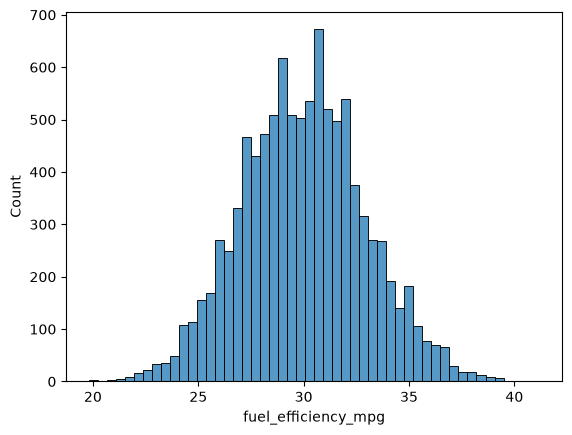

In [54]:
sns.histplot(df2["fuel_efficiency_mpg"], bins=50)

### Qestion 1

In [55]:
#Column with missing values
df2.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Question 2

In [56]:
#The median (50% percentile) for variable 'horsepower'
df2["horsepower"].median()

np.float64(254.0)

### Text here

In [57]:
#splitting rule
n = len(df2)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [58]:
#Shuffling dataset
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

In [59]:
#Splitting dataset
df_train = df2.iloc[idx[:n_train]]
df_val = df2.iloc[idx[n_train:n_train + n_val]]
df_test = df2.iloc[idx[n_train + n_val:]]

In [60]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7


In [61]:
#Resetting index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [62]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

### Question 3

**(A) Filling missing values in column 'horsepower' with 0**

In [63]:
df_train1 = df_train.copy()
df_val1 = df_val.copy()
df_test1 = df_test.copy()

In [64]:
df_train1["horsepower"] = df_train1["horsepower"].fillna(0)

In [65]:
df_train1.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,0.0,4150,1997,30.6
4,2340,269.0,4400,2001,30.7


In [66]:
y_train1 = df_train["fuel_efficiency_mpg"].values
y_val1 = df_val["fuel_efficiency_mpg"].values
y_test1 = df_test["fuel_efficiency_mpg"].values

In [67]:
del df_train1["fuel_efficiency_mpg"]
del df_val1["fuel_efficiency_mpg"]
del df_test1["fuel_efficiency_mpg"]

In [68]:
len(y_train1)

6000

In [69]:
df_train1.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,0.0,4150,1997
4,2340,269.0,4400,2001


**(Ai) Training linear regression model**

In [70]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [71]:
X_train1 = df_train1.values
X_train1

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [72]:
y_train1

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [73]:
w0, w = train_linear_regression(X_train1, y_train1)

In [74]:
w0

np.float64(-153.88496188223104)

In [75]:
w

array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01])

In [76]:
#Prediction
y_pred1 = w0 + X_train1.dot(w)

<Axes: ylabel='Count'>

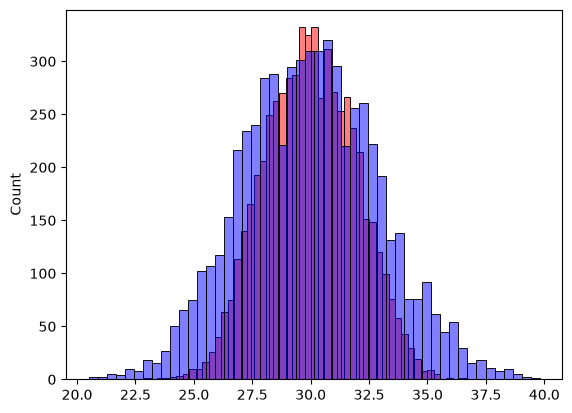

In [77]:
#Plot
sns.histplot(y_pred1, color='red', alpha=0.5, bins=50)
sns.histplot(y_train1, color='blue', alpha=0.5, bins=50)

**(Aii) Validating the model**

In [86]:
def prepare_X(df):
    df = df.fillna(0)
    X = df.values
    return X

In [87]:
#Training
X_val1 = prepare_X(df_val1)
w0, w = train_linear_regression(X_val1, y_val1)

In [88]:
w0

np.float64(-155.9810314669499)

In [89]:
w

array([-0.00087544, -0.0016548 , -0.00400707,  0.10280457])

In [91]:
#Predition
y_pred1 = w0 + X_val1.dot(w)
y_pred1

array([31.65163055, 29.94680012, 31.66350999, ..., 30.61447171,
       30.83245759, 31.58554139], shape=(2000,))

<Axes: ylabel='Count'>

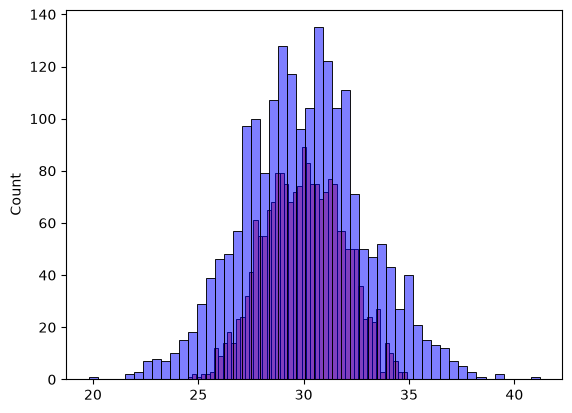

In [92]:
#Plot
sns.histplot(y_pred1, color='red', alpha=0.5, bins=50)
sns.histplot(y_val1, color='blue', alpha=0.5, bins=50)

**(Aiv) RMSE**

In [93]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [96]:
round(rmse(y_val1, y_pred1), 3)

np.float64(2.2)

**(B) Filling missing values in column 'horsepower' with column mean**